In [46]:
import torch 
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs
from sklearn.metrics import accuracy_score
from helper_function import plot_decision_boundary

In [21]:
X, y = make_blobs(n_samples = 1000, cluster_std = 1.5, centers = 4, random_state = 42)
X[:5]

array([[-8.41339595,  6.93516545],
       [-5.76648413, -6.43117072],
       [-6.04213682, -6.76610151],
       [ 3.95083749,  0.69840313],
       [ 4.25049181, -0.28154475]])

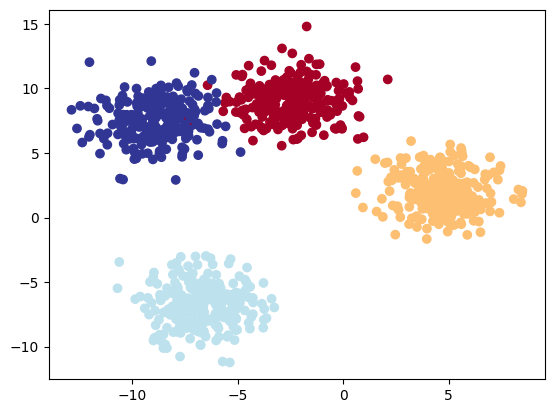

In [22]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [23]:
device = "mps" if torch.mps.is_available() else "cpu"
device

'mps'

In [24]:
X, y = torch.from_numpy(X).type(torch.float), torch.from_numpy(y).type(torch.float)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [26]:
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

In [27]:
X_train.shape, y_train.unique()

(torch.Size([800, 2]), tensor([0., 1., 2., 3.], device='mps:0'))

In [34]:
class BlobsModel(nn.Module):
    def __init__(self, in_features: int = 0, out_features: int = 0, hidden_units: int = 8):
        super().__init__()
        self.in_features: int = in_features
        self.out_features: int = out_features
        self.hidden_units: int = hidden_units
        
        self.layer = nn.Sequential(
            nn.Linear(self.in_features, self.hidden_units),
            nn.Linear(self.hidden_units, self.hidden_units),
            nn.Linear(self.hidden_units, self.out_features)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer(x)

In [35]:
model = BlobsModel(in_features = 2, out_features = 4, hidden_units = 10).to(device)
model

BlobsModel(
  (layer): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): Linear(in_features=10, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=4, bias=True)
  )
)

In [43]:
y_logits = torch.softmax(model(X_train), dim = 1, dtype = torch.float)
y_logits[0].argmax()

tensor(2, device='mps:0')

In [45]:
model.eval()
with torch.inference_mode():
    y_logits = torch.softmax(model(X_train), dim = 1, dtype = torch.float)
    y_pred = torch.argmax(y_logits, dim = 1)

y_pred[: 10], y_test[: 10]

(tensor([2, 2, 0, 0, 2, 2, 2, 2, 2, 2], device='mps:0'),
 tensor([1., 3., 2., 1., 0., 3., 2., 0., 2., 0.], device='mps:0'))

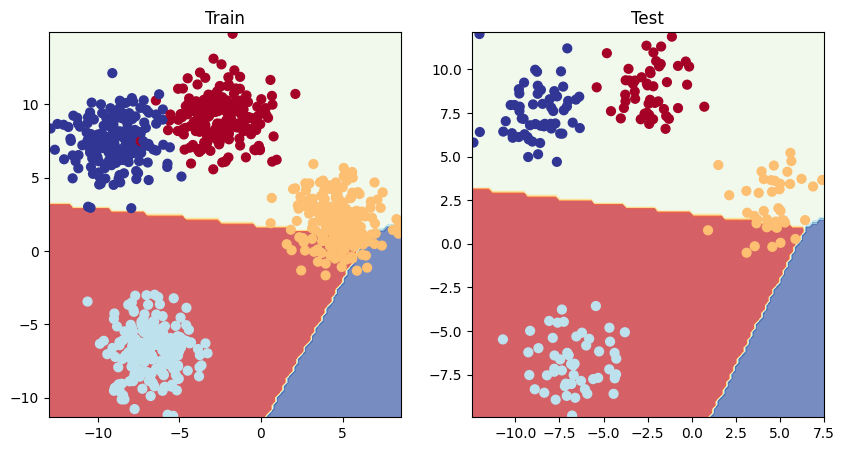

In [47]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)